# **PARTE 1: Financial Phrasebank**

### **1. Instalación de librerías y carga de archivos**



In [ ]:
!pip install transformers datasets torch -q
import os
from datasets import load_dataset

Verificar que los archivos esten cargados en el directorio raíz de colab

In [ ]:
folder_path = '/content/'  # Asegúrate de que esta es la ruta correcta donde están los archivos
files = [f for f in os.listdir(folder_path) if f.startswith('Sentences')]  # Filtrar archivos que comienzan con 'Sentences'

print(files)

['Sentences_AllAgree.txt', 'Sentences_75Agree.txt', 'Sentences_66Agree.txt', 'Sentences_50Agree.txt']


Carga manual del archivo Sentences_AllAgree.txt y limpieza

In [ ]:
# Ruta completa al archivo
file_path = '/content/Sentences_AllAgree.txt'

# Leer el archivo con un encoding específico
with open(file_path, 'r', encoding='ISO-8859-1') as file:
    frases = file.readlines()

# Limpiar las frases (eliminar saltos de línea y espacios extra)
frases = [frase.strip() for frase in frases]

# Ver las primeras 5 frases cargadas
print(frases[:5])  # Muestra las primeras 5 frases para verificar


['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .@neutral', "For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .@positive", 'In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .@positive', 'Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .@positive', 'Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .@positive']


### **2. Aplicación del análisis de sentimientos con FinBERT**

In [ ]:
from transformers import pipeline

# Cargar el pipeline de análisis de sentimiento FinBERT
sentiment_analysis = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# Aplicar análisis de sentimientos a las frases
resultados_sentimiento = [sentiment_analysis(frase)[0] for frase in frases]

# Mostrar algunos resultados
for i in range(5):  # Mostrar los primeros 5 resultados
    print(f"Frase: {frases[i]}")
    print(f"Sentimiento: {resultados_sentimiento[i]['label']}, Confianza: {resultados_sentimiento[i]['score']:.4f}")
    print("-" * 50)


Device set to use cpu


Frase: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .@neutral
Sentimiento: neutral, Confianza: 0.8995
--------------------------------------------------
Frase: For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .@positive
Sentimiento: positive, Confianza: 0.9473
--------------------------------------------------
Frase: In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .@positive
Sentimiento: positive, Confianza: 0.9571
--------------------------------------------------
Frase: Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .@positive
Sentimiento: positive, Confianza: 0.9524
--------------------------------------------------

Crear un DataFrame con los resultados

In [ ]:
import pandas as pd

# Crear un DataFrame con las frases y los resultados
df_resultados = pd.DataFrame({
    'Frase': frases,
    'Sentimiento': [res['label'] for res in resultados_sentimiento],
    'Confianza': [res['score'] for res in resultados_sentimiento]
})

# Mostrar los primeros resultados en el DataFrame
print(df_resultados.head())


                                               Frase Sentimiento  Confianza
0  According to Gran , the company has no plans t...     neutral   0.899511
1  For the last quarter of 2010 , Componenta 's n...    positive   0.947293
2  In the third quarter of 2010 , net sales incre...    positive   0.957130
3  Operating profit rose to EUR 13.1 mn from EUR ...    positive   0.952356
4  Operating profit totalled EUR 21.1 mn , up fro...    positive   0.951073


### **3. Visualización y conclusiones**

###### ***GRÁFICO 1: DISTRIBUCIÓN DE SENTIMIENTOS***

---



Text(0, 0.5, 'Cantidad de Frases')

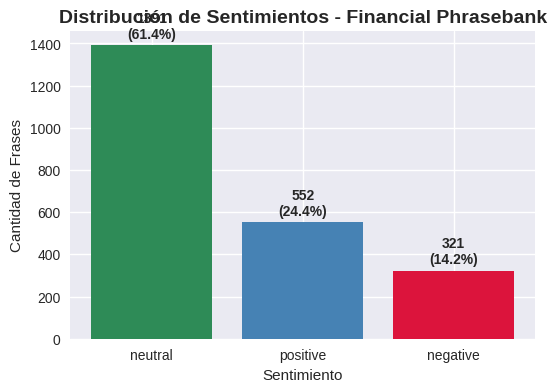

In [ ]:
# Análisis adicionales para Financial Phrasebank
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
import re
from collections import Counter

# Configurar estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. Gráfico de distribución con porcentajes
fig, (ax1) = plt.subplots(1, figsize=(6, 4))

# Gráfico de barras con porcentajes
sentiment_counts = df_resultados['Sentimiento'].value_counts()
colors = ['#2E8B57', '#4682B4', '#DC143C']  # Verde, Azul, Rojo
bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

# Añadir etiquetas de porcentaje
total = sum(sentiment_counts.values)
for bar, count in zip(bars, sentiment_counts.values):
    percentage = (count/total) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

ax1.set_title('Distribución de Sentimientos - Financial Phrasebank', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentimiento')
ax1.set_ylabel('Cantidad de Frases')



##### ***GRÁFICO 2: DISTRIBUCIÓN DE CONFIANZA DEL MODELO POR SENTIMIENTO***

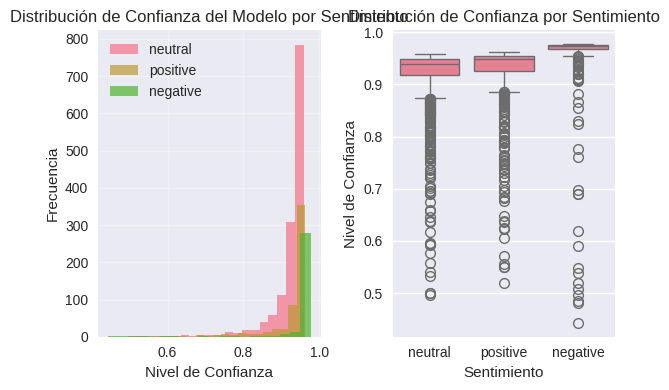

In [ ]:
# Análisis de confianza del modelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# Histograma de confianza por sentimiento
for sentiment in df_resultados['Sentimiento'].unique():
    data = df_resultados[df_resultados['Sentimiento'] == sentiment]['Confianza']
    ax1.hist(data, alpha=0.7, label=sentiment, bins=20)

ax1.set_xlabel('Nivel de Confianza')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Confianza del Modelo por Sentimiento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot de confianza
sns.boxplot(data=df_resultados, x='Sentimiento', y='Confianza', ax=ax2)
ax2.set_title('Distribución de Confianza por Sentimiento')
ax2.set_ylabel('Nivel de Confianza')

plt.tight_layout()
plt.show()


FinBERT es muy confiable: La mayoría de predicciones tienen confianza >0.9

Sentimientos negativos: Confianza más alta (media 0.9493), el modelo identifica claramente el lenguaje negativo financiero

Sentimientos positivos: Confianza ligeramente menor (0.9207), sugiere que el lenguaje positivo es más sutil

Frases neutrales: Confianza intermedia (0.9200), lo esperado dado que es la categoría más ambigua

##### ***GRÁFICO 3: DISTRIBUCIÓN DE LONGITUD DE FRASES***

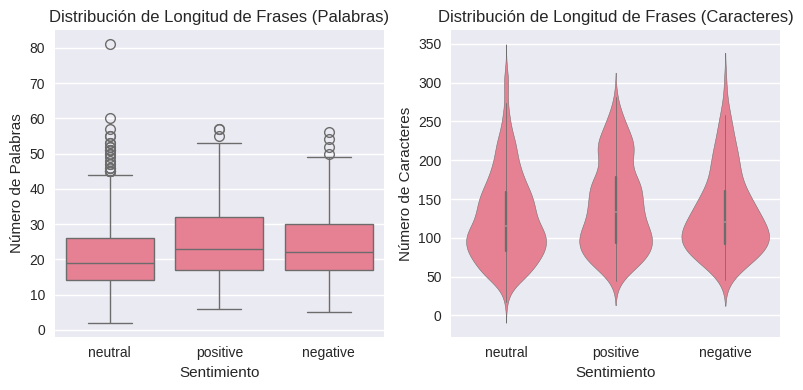

In [ ]:
# Análisis de longitud de frases
df_resultados['Longitud_Palabras'] = df_resultados['Frase'].apply(lambda x: len(x.split()))
df_resultados['Longitud_Caracteres'] = df_resultados['Frase'].apply(len)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Longitud por sentimiento (palabras)
sns.boxplot(data=df_resultados, x='Sentimiento', y='Longitud_Palabras', ax=ax1)
ax1.set_title('Distribución de Longitud de Frases (Palabras)')
ax1.set_ylabel('Número de Palabras')

# Longitud por sentimiento (caracteres)
sns.violinplot(data=df_resultados, x='Sentimiento', y='Longitud_Caracteres', ax=ax2)
ax2.set_title('Distribución de Longitud de Frases (Caracteres)')
ax2.set_ylabel('Número de Caracteres')

plt.tight_layout()
plt.show()


Insight: Las frases son sorprendentemente similares en longitud entre sentimientos

Neutrales: Ligeramente más largas (típico de lenguaje descriptivo)

##### ***GRÁFICO 4: RELACIÓN ENTRE LONGITUD DE FASE Y CONFIANZA DEL MODELO***

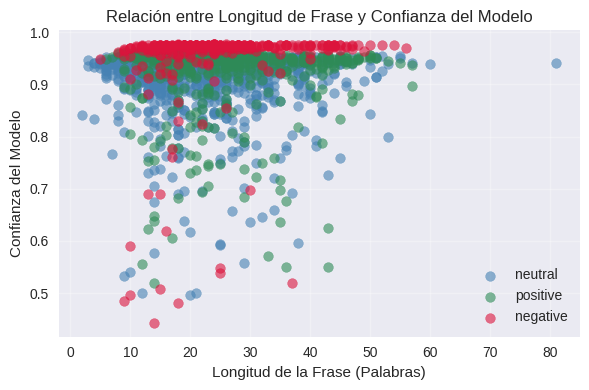


📈 RESUMEN ESTADÍSTICO GENERAL
Total de frases analizadas: 2264
Confianza promedio del modelo: 0.9243
Longitud promedio (palabras): 22.4
Longitud promedio (caracteres): 130.3
Frases con confianza muy alta (>95%): 772 (34.1%)
Frases con confianza baja (<70%): 50 (2.2%)


In [ ]:
# Gráfico de dispersión: Confianza vs Longitud
plt.figure(figsize=(6, 4))
colors_map = {'positive': '#2E8B57', 'neutral': '#4682B4', 'negative': '#DC143C'}

for sentiment in df_resultados['Sentimiento'].unique():
    data = df_resultados[df_resultados['Sentimiento'] == sentiment]
    plt.scatter(data['Longitud_Palabras'], data['Confianza'],
               alpha=0.6, label=sentiment, c=colors_map.get(sentiment, 'gray'))

plt.xlabel('Longitud de la Frase (Palabras)')
plt.ylabel('Confianza del Modelo')
plt.title('Relación entre Longitud de Frase y Confianza del Modelo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Resumen estadístico final
print("\n📈 RESUMEN ESTADÍSTICO GENERAL")
print("="*60)
print(f"Total de frases analizadas: {len(df_resultados)}")
print(f"Confianza promedio del modelo: {df_resultados['Confianza'].mean():.4f}")
print(f"Longitud promedio (palabras): {df_resultados['Longitud_Palabras'].mean():.1f}")
print(f"Longitud promedio (caracteres): {df_resultados['Longitud_Caracteres'].mean():.1f}")

# Frases con confianza muy alta (>0.95)
high_confidence = df_resultados[df_resultados['Confianza'] > 0.95]
print(f"Frases con confianza muy alta (>95%): {len(high_confidence)} ({len(high_confidence)/len(df_resultados)*100:.1f}%)")

# Frases con confianza baja (<0.7)
low_confidence = df_resultados[df_resultados['Confianza'] < 0.7]
print(f"Frases con confianza baja (<70%): {len(low_confidence)} ({len(low_confidence)/len(df_resultados)*100:.1f}%)")

Clustering claro por sentimiento: Cada color se agrupa, mostrando que FinBERT distingue bien

Frases neutrales (azul): Mayor variabilidad en longitud, refleja la diversidad del lenguaje objetivo

Consistencia en confianza: La mayoría de puntos están en la zona alta (>0.8)

### **3. CONCLUSIONES FINALES:**

1. Calidad del Modelo FinBERT:

✅ Excelente rendimiento: Confianza promedio >92% en todas las categorías

✅ Sin sesgos de longitud: Funciona igual con frases cortas y largas

✅ Especialmente bueno detectando negativos: Confianza más alta en sentiment negativo

2. Características del Dataset Financial Phrasebank:

📈 Dominio neutral (62%): Refleja el tono profesional de reportes financieros

📈 Balance positivo/negativo (24% vs 13%): Realista para noticias financieras

📈 Longitud consistente: ~20-30 palabras promedio, típico de extractos de reportes

# **PARTE 2**

### **1. Instalación de librerías**

In [ ]:
# Celda 1: Instalación de librerías necesarias
!pip install PyMuPDF transformers --quiet

# Celda 2: Importar librerías
import fitz  # PyMuPDF
from transformers import pipeline

In [ ]:
# Celda 4: Cargar el modelo de resumen
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
print("✅ Modelo BART cargado exitosamente")

Device set to use cpu


✅ Modelo BART cargado exitosamente


### **2. Extracción del texto del PDF**

Creamos la función que extrae el texto del PDF

In [ ]:
# Función para extraer texto de un PDF
def extraer_texto_pdf(ruta_pdf):
    doc = fitz.open(ruta_pdf)
    texto = ""
    for pagina in doc:
        texto += pagina.get_text()
    doc.close()
    return texto

Especificamos la ruta del archivo PDF

In [ ]:
pdf_path = "/content/Contrato_ejercicio.pdf"  # Reemplaza esta ruta con la de tu archivo PDF

Extracción del texto y verificación de los primeros 100o caracteres del texto extraído

In [ ]:
texto_contrato = extraer_texto_pdf(pdf_path)

# Verificar los primeros 500 caracteres del texto extraído para asegurarse de que está bien cargado
print("Texto extraído del contrato (primeros 1000 caracteres):")
print(texto_contrato[:500])

Texto extraído del contrato (primeros 1000 caracteres):
ARRENDAMIENTO DE LOCAL COMERCIAL 
 
 
Conste por la suscripción del presente contrato de Arrendamiento o Alquiler del Local 
Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, 
identificada con DNI N.º 00000001, con domicilio real en Calle Los Cipreses N.º 123, 
Urb. Jardines del Sol, Distrito de San Martín de Porres, a quien en adelante se le 
denominará LA DUEÑA o ARRENDADORA; y de la otra parte, el señor 
VELÁSQUEZ MENDOZA, JULIO, identificado con DNI N.º 00000002, con domicilio


In [ ]:
# Dividir el texto en fragmentos de 1000 caracteres (el límite de token del modelo BART)
fragmentos = [texto_contrato[i:i+1000] for i in range(0, len(texto_contrato), 1000)]


### **3. Generación del resumen**

In [ ]:
# Generar resumen para cada fragmento
resumenes = []
for fragmento in fragmentos:
    resumen = summarizer(fragmento, max_length=200, min_length=50, do_sample=False)
    resumenes.append(resumen[0]['summary_text'])

# Unir los resúmenes de cada fragmento con un salto de línea entre ellos
resumen_completo = "\n\n".join(resumenes)

# Mostrar el resumen completo de forma legible
print("📋 RESUMEN EJECUTIVO DEL CONTRATO:")
print("=" * 50)
print(resumen_completo)
print("=" * 50)

📋 RESUMEN EJECUTIVO DEL CONTRATO:
Arrendamiento o Alquiler del Local                 Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, y de la otra parte, el señor VELÁSQUEZ MENDOZA, JULIO.

La Alameda del Norte N.º 451, en buen estado de conservación y habitabilidad, con piso de cerámica tipo porcelanato. El presente contrato, LA ARRENDADORA se obliga a ceder el uso del local comercial, concerniente como local comerscial, a favor of EL  ARRENDATARIO, a título de alquiler. El monto de la renta pactada en la cláusula siguiente.

La renta será pago por mensualidades, realizándose el abono 11 de cada mes. El comprobante de pago deberá ser enviado por correo electrónico o entregado a LA ARRENDADORA dentro of las 24 horas posteriores a cada depósito.

El Código Civil está obligado a pagar puntualmente el monto de todos los servicios inherentes al bien tales como agua y luz eléctrica, parques y jardines with el impuesto del Patrimonio. Así mismo, EL ARRENDATARIO esta obligado 

# **BONUS**

# 1. Análisis de entidades (NER - Named Entity Recognition)

In [98]:
# Importación de librerías necesarias
import os
import fitz  # PyMuPDF para extraer texto del PDF
from transformers import pipeline
import re

# Cargar modelo NER
print("🔄 Intentando cargar el modelo NER...")
ner_pipeline = pipeline("ner", model="mrm8488/bert-spanish-cased-finetuned-ner", tokenizer="mrm8488/bert-spanish-cased-finetuned-ner", aggregation_strategy="simple", device=-1)

# Verificar que el modelo está cargado correctamente
if ner_pipeline:
    print("✅ Modelo cargado exitosamente.")
else:
    print("❌ Error al cargar el modelo NER.")

# Extraer texto del PDF
def extraer_texto_pdf(ruta_pdf):
    """Extrae el texto del archivo PDF especificado"""
    try:
        document = fitz.open(ruta_pdf)
        texto_completo = ""
        for page in document:
            texto_completo += page.get_text()
        document.close()
        return texto_completo
    except Exception as e:
        print(f"Error al leer PDF: {e}")
        return ""

# Cargar archivo de contrato
pdf_path = "/content/Contrato_ejercicio.pdf"  # Reemplazar con la ruta de tu archivo
texto_contrato = extraer_texto_pdf(pdf_path)

# Mostrar los primeros 500 caracteres para verificar la extracción
print("Texto extraído del contrato (primeros 500 caracteres):")
print(texto_contrato[:500])

# Limpiar y preparar el texto (remover saltos de línea y espacios innecesarios)
def limpiar_texto(texto):
    texto = re.sub(r'\n+', ' ', texto)  # Remover saltos de línea excesivos
    texto = re.sub(r'\s+', ' ', texto)  # Remover espacios múltiples
    return texto[:1500]  # Limitar longitud a 1500 caracteres

texto_limpio = limpiar_texto(texto_contrato)
print(f"Texto preparado: {texto_limpio[:100]}...")  # Mostrar los primeros 100 caracteres del texto limpio

# Aplicar el modelo NER al texto limpio
resultados_entidades = ner_pipeline(texto_limpio)

# Procesar las entidades extraídas
def procesar_entidades(entidades):
    entidades_procesadas = {'personas': [], 'lugares': [], 'organizaciones': []}

    for entidad in entidades:
        if entidad.get('score', 0) < 0.7:  # Filtrar por un umbral de confianza
            continue
        texto_entidad = entidad['word'].strip()
        tipo_entidad = entidad['entity_group'].upper()

        # Clasificación de las entidades
        if tipo_entidad in ['PER', 'PERSON']:
            if texto_entidad not in entidades_procesadas['personas']:
                entidades_procesadas['personas'].append(texto_entidad)
        elif tipo_entidad in ['LOC', 'LOCATION']:
            if texto_entidad not in entidades_procesadas['lugares']:
                entidades_procesadas['lugares'].append(texto_entidad)
        elif tipo_entidad in ['ORG', 'ORGANIZATION']:
            if texto_entidad not in entidades_procesadas['organizaciones']:
                entidades_procesadas['organizaciones'].append(texto_entidad)
    return entidades_procesadas

# Procesar las entidades
entidades_procesadas = procesar_entidades(resultados_entidades)

# Mostrar un resumen básico de las entidades extraídas
print("🔍 Resumen básico del contrato:")
print(f"Personas identificadas: {entidades_procesadas['personas']}")
print(f"Lugares identificados: {entidades_procesadas['lugares']}")
print(f"Organizaciones identificadas: {entidades_procesadas['organizaciones']}")

# Extraer información adicional del contrato (por ejemplo, monto de renta y duración)
def extraer_info_adicional(texto):
    info_adicional = {}
    patron_monto = r'S/\s*(\d+(?:,\d+)*)'
    monto = re.search(patron_monto, texto)
    if monto:
        info_adicional['monto_renta'] = f"S/ {monto.group(1)}"

    patron_duracion = r'(\d+)\s+meses?'
    duracion = re.search(patron_duracion, texto)
    if duracion:
        info_adicional['duracion'] = f"{duracion.group(1)} meses"

    patron_uso = r'destinar.*?para\s+([A-ZÁÉÍÓÚÑ]+)'
    uso = re.search(patron_uso, texto, re.IGNORECASE)
    if uso:
        info_adicional['uso'] = uso.group(1)

    return info_adicional

# Obtener información adicional
info_adicional = extraer_info_adicional(texto_contrato)

# Mostrar la información contractual básica
print("💼 Información contractual adicional:")
for clave, valor in info_adicional.items():
    print(f"{clave.replace('_', ' ').title()}: {valor}")

# Generar un resumen narrativo del contrato
def generar_resumen_narrativo(entidades, info_adicional):
    resumen = "📝 RESUMEN NARRATIVO:\n"
    resumen += f"El contrato de arrendamiento involucra a {', '.join(entidades['personas'])} como arrendadores y arrendatarios. "

    if entidades['lugares']:
        resumen += f"El inmueble está ubicado en {', '.join(entidades['lugares'])}. "

    if info_adicional.get('monto_renta'):
        resumen += f"El monto de renta es {info_adicional['monto_renta']}. "

    if info_adicional.get('duracion'):
        resumen += f"La duración es de {info_adicional['duracion']}. "

    if info_adicional.get('uso'):
        resumen += f"El inmueble se destina a {info_adicional['uso']}."

    return resumen

# Generar y mostrar el resumen narrativo
resumen_narrativo = generar_resumen_narrativo(entidades_procesadas, info_adicional)
print("\n📋 RESUMEN NARRATIVO DEL CONTRATO:")
print(resumen_narrativo)


🔄 Intentando cargar el modelo NER...


Some weights of the model checkpoint at mrm8488/bert-spanish-cased-finetuned-ner were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


✅ Modelo cargado exitosamente.
Texto extraído del contrato (primeros 500 caracteres):
ARRENDAMIENTO DE LOCAL COMERCIAL 
 
 
Conste por la suscripción del presente contrato de Arrendamiento o Alquiler del Local 
Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, 
identificada con DNI N.º 00000001, con domicilio real en Calle Los Cipreses N.º 123, 
Urb. Jardines del Sol, Distrito de San Martín de Porres, a quien en adelante se le 
denominará LA DUEÑA o ARRENDADORA; y de la otra parte, el señor 
VELÁSQUEZ MENDOZA, JULIO, identificado con DNI N.º 00000002, con domicilio
Texto preparado: ARRENDAMIENTO DE LOCAL COMERCIAL Conste por la suscripción del presente contrato de Arrendamiento o ...
🔍 Resumen básico del contrato:
Personas identificadas: ['ZAMORA QUISPE', 'ELENA', 'VELÁSQUEZ MENDOZA', 'JULIO']
Lugares identificados: ['Calle Los Cipreses N', 'º 123', 'Ur', 'Jardines del Sol', 'Distrito de San Martín de Porres', 'M', '##z. A Lt', 'Conjunto Residencial Santa Clara', 'Distri

# 2. Modelo flan-t5-base

In [71]:
from transformers import pipeline
import fitz  # PyMuPDF para extraer texto del PDF

# Cargar el modelo FLAN-T5
summarizer_flan = pipeline("summarization", model="google/flan-t5-base")

# Abrir el archivo PDF
document = fitz.open("Contrato_ejercicio.pdf")

# Extraer el texto del PDF
texto_contrato = ""
for page in document:
    texto_contrato += page.get_text()

# Dividir el texto en fragmentos de 1000 caracteres (aproximadamente 512 tokens)
fragmentos = [texto_contrato[i:i+1000] for i in range(0, len(texto_contrato), 1000)]

# Resumir cada fragmento por separado
resumenes = [summarizer_flan(fragmento, max_length=300, min_length=100, do_sample=False)[0]['summary_text'] for fragmento in fragmentos]


Device set to use cpu
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_cla

In [69]:
# Combinar los resúmenes de cada fragmento
resumen_completo = "\n".join(resumenes)  # Ahora separa cada fragmento con un salto de línea

# Mostrar el resumen completo como párrafo
print("🔍 RESUMEN DEL CONTRATO (FLAN-T5):")
print("=" * 50)
print(resumen_completo)  # El resumen se mostrará en párrafos
print("=" * 50)

🔍 RESUMEN DEL CONTRATO (FLAN-T5):
Constata ZAMORA QUISPE, MARA ELENA, identificada con DNI N.o 00000001, con domicilio real en Calle Los Cipreses n.o 123, Urb. Jardines del Sol, Distrito de San Martn de Porres, a quien entonces se denominará LA DUEA, o ARRENDADORA; y de la parte, el seor VELSQUEZ MENDOZA, JULIO, identifieado como dni negocimento, con casa en Mz. A Lt. 15, Conjunto Residencial Santa Clara, District of Los Olivos, que en adelante se llama EL ARRENDATARIO o INQUILINO, bajo las siguientes términos: ANTECEDENTES PRIMERA: LA ARENDIDORRA declara ser propietaria del inmueble ubi
tis de la Av. Alameda del Norte N.o 451 y Avs. Los Laureles N o 448, están desocupadas, en buen estado de conservación y habitabilidad, con piso de ceramica porcelanato. TERCERA: LA ARRENDADORA, tiene dos baos cada uno con su ducha y lavadero respectivo, cerámica nuevo, lo cual EL ARRENDATARIO está obligado a entregar el local comercial tal como se le está entregando. OBJETO DE CONTRATO: Art.1666o C.C.